In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**tl;dr**

Turned the raw scraped data into dataframes. Combined with other data.

| df | discp. | 
| :--- | :---: |
| `df_raw`| raw gas data | 
| `df_gas` | only "current average" rows  | 
| `df_laud`| Pretaining to Ft. Lauderdale  | 
| `df_metro` | raw data for coordinates and metros | 
| `df_gas_coor` | gas and coordinates | 


Made some time series viz, not much insight 

# Cleaning AAA wayback historic gas data

In [8]:
df_raw = pd.read_csv('Data/gas_data.csv')
df_raw.head()

,date,metro,regular,mid,premium,reg_delt
0,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,NaN
1,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,0.000000
2,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,19.516562
3,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000
4,2022-03-08,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000


The raw data contains the date, metro, and gas price for that day. 

In [23]:
df_raw.isna()

df_raw.isna().sum()

date         0
metro        0
regular      0
mid          0
premium      0
reg_delt    24
dtype: int64

Data looks tidy. No missing values or nas except for the Regular Delt column. 

In [10]:
df_gas = df_raw[["date", "metro", "regular", "mid", "premium"]]
df_gas.head()

,date,metro,regular,mid,premium
0,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006
1,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006
2,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603
3,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603
4,2022-03-08,Bradenton-Sarasota-Venice,4.005,4.292,4.603


date / time

In [11]:
df_gas["date"] = pd.to_datetime(df_gas["date"])
df_gas["date"].dtype

/var/folders/9n/xcff1phn0m54z30p0b7kb0k00000gn/T/ipykernel_54385/3436994774.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gas["date"] = pd.to_datetime(df_gas["date"])


dtype('<M8[ns]')

In [12]:
df_gas.dtypes

date       datetime64[ns]
metro              object
regular           float64
mid               float64
premium           float64
dtype: object

Percent change

In [13]:
df_gas = df_gas.sort_values(['metro', 'date'])

df_gas['reg_delt'] = (
    df_gas
    .groupby('metro')['regular']
    .pct_change() * 100
)

df_gas.head()

,date,metro,regular,mid,premium,reg_delt
0,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,NaN
1,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,0.000000
2,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,19.516562
3,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000
4,2022-03-08,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000


Depending on what **metros** we choose, can be adjusted

In [14]:
df_laud = df_gas[df_gas["metro"] == "Fort Lauderdale"]

df_laud.head()

,date,metro,regular,mid,premium,reg_delt
1443,2022-01-28,Fort Lauderdale,3.373,3.741,4.039,NaN
1444,2022-01-28,Fort Lauderdale,3.373,3.741,4.039,0.000000
1445,2022-03-07,Fort Lauderdale,4.035,4.306,4.614,19.626445
1446,2022-03-07,Fort Lauderdale,4.035,4.306,4.614,0.000000
1447,2022-03-08,Fort Lauderdale,4.035,4.306,4.614,0.000000


## Visualizing gas data 

#### Ft. Lauderdale 2025

> We could filter to a smaller range when we decide what hurricane to look at 

In [15]:
df_laud25 = df_laud[df_laud["date"].between("2025-06-01", "2025-11-30")]

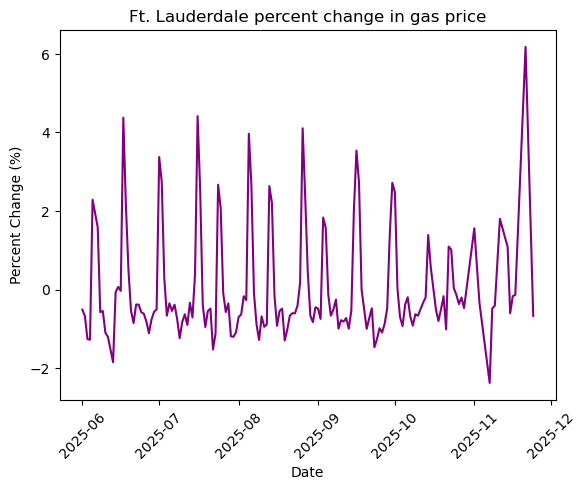

In [16]:
plt.plot(df_laud25["date"], df_laud25["reg_delt"], color = "purple")
plt.title("Ft. Lauderdale percent change in gas price")
plt.xlabel("Date")
plt.xticks(rotation = 45)
plt.ylabel("Percent Change (%)")
plt.grid(False)

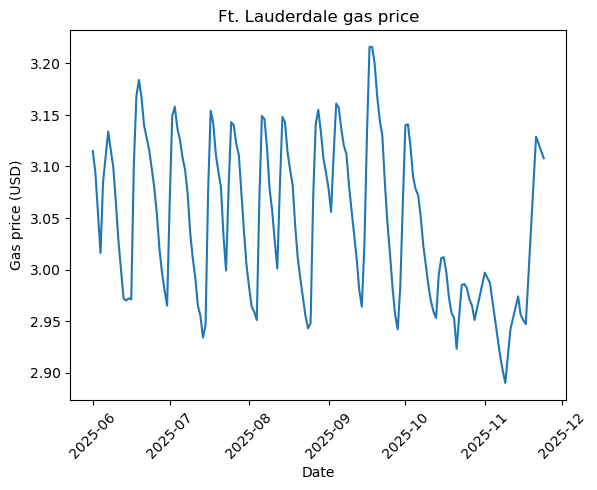

In [17]:
plt.plot(df_laud25["date"], df_laud25["regular"])
plt.title("Ft. Lauderdale gas price")
plt.xlabel("Date")
plt.xticks(rotation = 45)
plt.ylabel("Gas price (USD)")
plt.grid(False)

In [18]:
df_laud25["date"].dtype

dtype('<M8[ns]')

> After integrating the hurricane data, we could do maybe automated shading / landfall plotting

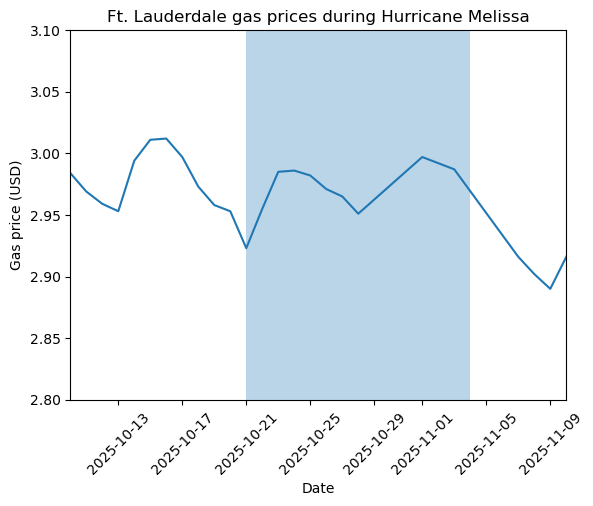

In [19]:
plt.plot(df_laud25["date"], df_laud25["regular"])
plt.xlim(pd.to_datetime("2025-10-10"), pd.to_datetime("2025-11-10"))
plt.ylim(2.8, 3.10)
plt.title("Ft. Lauderdale gas prices during Hurricane Melissa")
plt.xlabel("Date")
plt.xticks(rotation = 45)
plt.ylabel("Gas price (USD)")
plt.axvspan(pd.to_datetime("2025-10-21"), 
            pd.to_datetime("2025-11-04"), alpha = 0.3)

In [20]:
df_pens = df_gas[df_gas["metro"] == "Pensacola"]

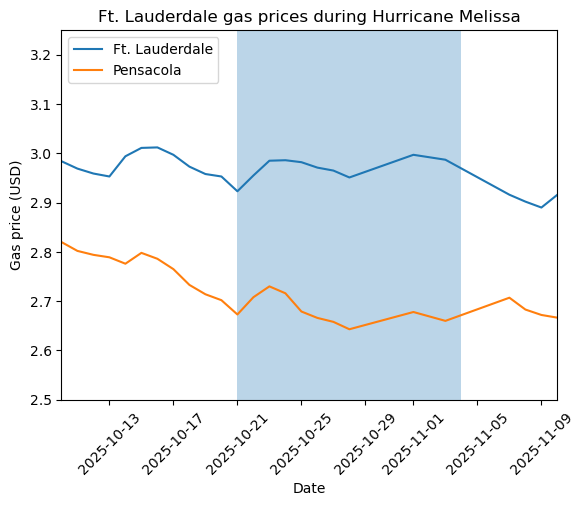

In [21]:
plt.plot(df_laud25["date"], df_laud25["regular"], label = "Ft. Lauderdale")
plt.plot(df_pens["date"], df_pens["regular"], label = "Pensacola")
plt.legend()
plt.ylim(2.5, 3.25)
plt.xlim(pd.to_datetime("2025-10-10"), pd.to_datetime("2025-11-10"))
plt.title("Ft. Lauderdale gas prices during Hurricane Melissa")
plt.xlabel("Date")
plt.xticks(rotation = 45)
plt.ylabel("Gas price (USD)")
plt.axvspan(pd.to_datetime("2025-10-21"), 
            pd.to_datetime("2025-11-04"), alpha = 0.3)

#### Potential ideas?

* show difference (either abs or pct change) from when a hurricane hit to when it stopped, like a little verticle line or something 
* would be cool to show on the line the different hurricane category per city in the same time frame 
 

# Data integration pt 1 (gas and metros -> gas coordinates)

### Coordinates to Metros

https://simplemaps.com/data/us-metros

In [22]:
path = "/Users/Local/canes/HurricanesAndGasPrices/Data/usmetros.csv"
df_geo = pd.read_csv(path)
df_geo.columns = df_geo.columns.str.lower()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/Local/canes/HurricanesAndGasPrices/Data/usmetros.csv'

In [ ]:
df_fl_coor = df_geo[df_geo["state_id"] == "FL"]
df_fl_coor.head()

,metro_fips,metro,metro_ascii,metro_full,county_name,county_fips,state_id,state_name,lat,lng,population
5,33100,Miami,Miami,"Miami-Fort Lauderdale-West Palm Beach, FL",Palm Beach,12099,FL,Florida,26.1573,-80.5059,6457988
16,45300,Tampa,Tampa,"Tampa-St. Petersburg-Clearwater, FL",Hillsborough,12057,FL,Florida,28.1538,-82.4050,3424560
19,36740,Orlando,Orlando,"Orlando-Kissimmee-Sanford, FL",Osceola,12097,FL,Florida,28.4343,-81.3630,2940513
37,27260,"Jacksonville, FL","Jacksonville, FL","Jacksonville, FL",Duval,12031,FL,Florida,30.2366,-81.7923,1760548
60,35840,North Port,North Port,"North Port-Bradenton-Sarasota, FL",Manatee,12081,FL,Florida,27.3479,-82.3223,934956


### Name mapping 

Matching names between `geographic df` and `gas df`

1. Split df_fl_coor["metro_full"] to parse FL out
2. Mapped names from `df_gas["metro]` and `df_fl_coor["met"]` 

##### 1. Split `df_fl_coor[metro]` into two columns (get Fl out)

In [ ]:
df_fl_coor["metro_full"]= df_fl_coor["metro_full"].astype(str)
df_fl_coor["metro_full"].dtype

<StringDtype(storage='python', na_value=nan)>

In [ ]:
df_fl_coor[["met", "state"]] = df_fl_coor["metro_full"].str.split(",", expand = True)

In [ ]:
df_gas["metro"].unique()

<StringArray>
[      'Bradenton-Sarasota-Venice',     'Crestview-Fort Walton Beach',
                   'Daytona Beach',                 'Fort Lauderdale',
           'Fort Myers-Cape Coral',                     'Gainesville',
               'Homosassa Springs',                    'Jacksonville',
           'Lakeland-Winter Haven',            'Melbourne-Titusville',
                           'Miami',                          'Naples',
                           'Ocala',                         'Orlando',
                     'Panama City',                       'Pensacola',
                  'Port St. Lucie',                     'Punta Gorda',
            'Sebastian-Vero Beach',                         'Sebring',
                     'Tallahassee', 'Tampa-St. Petersburg-Clearwater',
                    'The Villages',      'West Palm Beach-Boca Raton']
Length: 24, dtype: str

In [ ]:
df_fl_coor["met"].unique()

<StringArray>
[  'Miami-Fort Lauderdale-West Palm Beach',
         'Tampa-St. Petersburg-Clearwater',
               'Orlando-Kissimmee-Sanford',
                            'Jacksonville',
           'North Port-Bradenton-Sarasota',
                   'Cape Coral-Fort Myers',
                   'Lakeland-Winter Haven',
      'Deltona-Daytona Beach-Ormond Beach',
           'Palm Bay-Melbourne-Titusville',
                          'Port St. Lucie',
              'Pensacola-Ferry Pass-Brent',
                                   'Ocala',
                     'Naples-Marco Island',
                             'Tallahassee',
                             'Gainesville',
      'Crestview-Fort Walton Beach-Destin',
           'Panama City-Panama City Beach',
                             'Punta Gorda',
 'Sebastian-Vero Beach-West Vero Corridor',
                       'Homosassa Springs',
                   'Wildwood-The Villages',
                                 'Sebring']
Length: 22, dtype:

##### 2. Mapped names from `df_gas["metro]` and `df_fl_coor["met"]` 

| `df_gas["metro]`| `df_fl_coor["met"]` | Match? |
| :--- | :--- | :---: | 
| Bradenton-Sarasota-Venice | North Port-Bradenton-Sarasota | No |
| Daytona Beach | Deltona-Daytona Beach-Ormond Beach | No |
| Fort Myers-Cape Coral | Cape Coral-Fort Myers | No |
| Homosassa Springs | Homosassa Springs | Yes |
| Miami | Miami-Fort Lauderdale-West Palm Beach | No |
| Fort Lauderdale | Miami-Fort Lauderdale-West Palm Beach | No |
| Ocala | Ocala | Yes |
| Panama City | Panama City-Panama City Beach | No |
| Port St. Lucie | Port St. Lucie | Yes |
| Sebastian-Vero Beach | Sebastian-Vero Beach-West Vero Corridor | No |
| Tallahassee | Tallahassee | Yes |
| The Villages | Wildwood-The Villages | No |
| Crestview-Fort Walton Beach | Crestview-Fort Walton Beach-Destin | No |
| Gainesville | Gainesville | Yes |
| Jacksonville | Jacksonville | Yes |
| Melbourne-Titusville | --- | No |
| Naples | Naples-Marco Island | No |
| Orlando | Orlando-Kissimmee-Sanford | No |
| Pensacola | Pensacola | Yes |
| Punta Gorda | Punta Gorda | Yes |
| Sebring| Sebring | Yes |
| Tampa-St. Petersburg-Clearwater | Tampa | No |

In [ ]:
map = {
    "Bradenton-Sarasota-Venice" : "North Port-Bradenton-Sarasota",
    "Daytona Beach" : "Deltona-Daytona Beach-Ormond Beach",
    "Fort Myers-Cape Coral" : "Cape Coral-Fort Myers",
    "Homosassa Springs": "Homosassa Springs",
    "Miami" : "Miami-Fort Lauderdale-West Palm Beach",
    "Fort Lauderdale" : "Miami-Fort Lauderdale-West Palm Beach",
    "Ocala" : "Ocala",
    "Panama City" :  "Panama City-Panama City Beach",
    "Port St. Lucie" : "Port St. Lucie",
    "Sebastian-Vero Beach" : "Sebastian-Vero Beach-West Vero Corridor",
    "Tallahassee": "Tallahassee",
    "The Villages" : "Wildwood-The Villages",
    "Crestview-Fort Walton Beach" : "Crestview-Fort Walton Beach-Destin",
    "Gainesville" : "Gainesville",
    "Jacksonville" : "Jacksonville",
    "Melbourne-Titusville" : "Melbourne-Titusville",
    "Naples" : "Naples-Marco Island",
    "Orlando" : "Orlando-Kissimmee-Sanford",
    "Pensacola" : "Pensacola-Ferry Pass-Brent",
    "Sebring" : "Sebring",
    "Tampa" : "Tampa-St. Petersburg-Clearwater",
}

df_gas["metro"] = df_gas["metro"].astype(str).str.strip()
df_gas["met"] = df_gas["metro"].map(map).fillna(df_gas["metro"])

In [ ]:
df_name_check = df_gas[["metro", "met"]]

confused

In [ ]:
gas_set = set(df_gas["met"].astype(str).str.strip())
coo_set = set(df_fl_coor["met"].astype(str).str.strip())

print(gas_set)
print(coo_set)
not_map =  gas_set - coo_set
print(not_map)

{'West Palm Beach-Boca Raton', 'Sebastian-Vero Beach-West Vero Corridor', 'Gainesville', 'Homosassa Springs', 'Crestview-Fort Walton Beach-Destin', 'Melbourne-Titusville', 'Sebring', 'Tampa-St. Petersburg-Clearwater', 'Miami-Fort Lauderdale-West Palm Beach', 'Jacksonville', 'Lakeland-Winter Haven', 'Tallahassee', 'Punta Gorda', 'North Port-Bradenton-Sarasota', 'Naples-Marco Island', 'Orlando-Kissimmee-Sanford', 'Deltona-Daytona Beach-Ormond Beach', 'Panama City-Panama City Beach', 'Wildwood-The Villages', 'Cape Coral-Fort Myers', 'Port St. Lucie', 'Pensacola-Ferry Pass-Brent', 'Ocala'}
{'Sebastian-Vero Beach-West Vero Corridor', 'Gainesville', 'Homosassa Springs', 'Crestview-Fort Walton Beach-Destin', 'Sebring', 'Tampa-St. Petersburg-Clearwater', 'Miami-Fort Lauderdale-West Palm Beach', 'Jacksonville', 'Lakeland-Winter Haven', 'Tallahassee', 'Punta Gorda', 'North Port-Bradenton-Sarasota', 'Naples-Marco Island', 'Palm Bay-Melbourne-Titusville', 'Orlando-Kissimmee-Sanford', 'Deltona-Dayt

### Coordinate putting

Putting the coordinates from `df_fl_coor` onto `df_gas`

In [ ]:
df_gas_coor = df_gas.merge(
    df_fl_coor[["met", "lat", "lng"]],
    on = "met",
    how = "left"
)

In [ ]:
sorted(df_fl_coor["met"].unique())

['Cape Coral-Fort Myers',
 'Crestview-Fort Walton Beach-Destin',
 'Deltona-Daytona Beach-Ormond Beach',
 'Gainesville',
 'Homosassa Springs',
 'Jacksonville',
 'Lakeland-Winter Haven',
 'Miami-Fort Lauderdale-West Palm Beach',
 'Naples-Marco Island',
 'North Port-Bradenton-Sarasota',
 'Ocala',
 'Orlando-Kissimmee-Sanford',
 'Palm Bay-Melbourne-Titusville',
 'Panama City-Panama City Beach',
 'Pensacola-Ferry Pass-Brent',
 'Port St. Lucie',
 'Punta Gorda',
 'Sebastian-Vero Beach-West Vero Corridor',
 'Sebring',
 'Tallahassee',
 'Tampa-St. Petersburg-Clearwater',
 'Wildwood-The Villages']

In [ ]:
df_gas_coor.head()

,date,metro,regular,mid,premium,reg_delt,met,lat,lng
0,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,NaN,North Port-Bradenton-Sarasota,27.3479,-82.3223
1,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,0.000000,North Port-Bradenton-Sarasota,27.3479,-82.3223
2,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,19.516562,North Port-Bradenton-Sarasota,27.3479,-82.3223
3,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000,North Port-Bradenton-Sarasota,27.3479,-82.3223
4,2022-03-08,Bradenton-Sarasota-Venice,4.005,4.292,4.603,0.000000,North Port-Bradenton-Sarasota,27.3479,-82.3223


In [ ]:
df_gas_coor.to_csv("gas_coordinates.csv", index = False)

# Data integration pt 2 (gas coordinates + hurricane data -> gas hurricane)

In [ ]:
# df_gas_coor = pd.read_csv("gas_coordinates.csv") 

In [ ]:
path = "/Users/Local/hurricanes_data.csv"

df_canes = pd.read_csv(path)
df_canes.head()

/var/folders/9n/xcff1phn0m54z30p0b7kb0k00000gn/T/ipykernel_5132/707415178.py:3: DtypeWarning: Columns (0: SEASON, 1: NUMBER, 2: LAT, 3: LON, 4: DIST2LAND, 5: USA_LAT, 6: USA_LON, 7: STORM_SPEED, 8: STORM_DIR) have mixed types. Specify dtype option on import or set low_memory=False.
  df_canes = pd.read_csv(path)


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,,Year,,,,,,,degrees_north,degrees_east,...,second,kts,second,ft,nmile,nmile,nmile,nmile,kts,degrees
1,2023005S18142,2023,1,SP,EA,HALE,2023-01-04 18:00:00,DS,-18.2,142.0,...,,,,,,,,,9,85
2,2023005S18142,2023,1,SP,EA,HALE,2023-01-04 21:00:00,DS,-18.1,142.5,...,,,,,,,,,10,85
3,2023005S18142,2023,1,SP,EA,HALE,2023-01-05 00:00:00,DS,-18.1,143.0,...,,,,,,,,,10,85
4,2023005S18142,2023,1,SP,EA,HALE,2023-01-05 03:00:00,DS,-18.1,143.5,...,,,,,,,,,10,90


## Data cleaning and preprocessing

In [ ]:
##

#### Handling issues / noise in the data

There were no missing values in the original data frame. The original scraped .csv was tidy. 

However, there are rows with different differences in dates between them, suggesting entire missing rows rather than rows with missing column entries. 

In [ ]:
df_raw.isna().sum()

NameError: name 'df_raw' is not defined